# LAB05 — Tasks 2.2–2.5

Point numbering for §2.3–2.4: **1** base, **2** intermediate joint, **3** end-effector. Task 2.4 uses extra mass `m0` at the sliding base.



In [23]:
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import FileLink, display
from scipy.integrate import solve_ivp  

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

CWD = Path.cwd().resolve()
if (CWD / "LAB05").exists():
    REPO_ROOT = CWD
elif CWD.name == "LAB05":
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

EXPORT_DIR = REPO_ROOT / "LAB05" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Exports folder: {EXPORT_DIR.resolve()}")

(EXPORT_DIR / "exports_test.txt").write_text("export ok\n", encoding="utf-8")
print("Wrote:", (EXPORT_DIR / "exports_test.txt").resolve())


def visualize_double_pendulum(points,
                              stats=None,
                              dt=0.01,
                              trace_len=0.1,
                              save=False,
                              save_path=None,
                              verbose=True,
                              axes=False,
                              show=True,
                              close_fig=False):
    if len(points) == 2:
        x0 = np.zeros_like(points[0][0])
        y0 = np.zeros_like(points[0][1])
        x1, y1 = points[0]
        x2, y2 = points[1]
    elif len(points) == 3:
        (x0, y0), (x1, y1), (x2, y2) = points
    else:
        raise ValueError("points must contain either 2 or 3 planar points")

    LEN = len(x1)

    L1 = ((x1[0] - x0[0])**2 + (y1[0] - y0[0])**2)**0.5
    L2 = ((x2[0] - x1[0])**2 + (y2[0] - y1[0])**2)**0.5
    all_x = np.concatenate([x0, x1, x2])
    all_y = np.concatenate([y0, y1, y2])
    L_MAX = 1.1*max(np.max(np.abs(all_x)), np.max(np.abs(all_y)), L1 + L2, 1.0)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(autoscale_on=False,
                         xlim=(-L_MAX, L_MAX), ylim=(-L_MAX, L_MAX))
    ax.set_aspect('equal', adjustable='box')
    if axes:
        ax.grid(color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    else:
        plt.axis('off')

    line, = ax.plot([], [], '-', c='black', lw=2)
    circle_0, = ax.plot([], [], 'o', c='black', markersize=6, zorder=5)
    circle_1, = ax.plot([], [], 'o', c='blue', markersize=6, zorder=5)
    circle_2, = ax.plot([], [], 'o', c='red', markersize=6, zorder=5)

    trace, = ax.plot([], [], '-', c='r', lw=1, alpha=0.2)

    corner_text = ax.text(0.05, 0.8, '', transform=ax.transAxes, zorder=10)
    history_x, history_y = deque(maxlen=int(
        trace_len*LEN)), deque(maxlen=int(trace_len*LEN))

    def animate(i):
        stat_text = ''
        thisx = [x0[i], x1[i], x2[i]]
        thisy = [y0[i], y1[i], y2[i]]

        if i == 0:
            history_x.clear()
            history_y.clear()

        history_x.appendleft(thisx[2])
        history_y.appendleft(thisy[2])

        line.set_data(thisx, thisy)
        circle_0.set_data([x0[i]], [y0[i]])
        circle_1.set_data([x1[i]], [y1[i]])
        circle_2.set_data([x2[i]], [y2[i]])
        trace.set_data(history_x, history_y)

        if stats is not None:
            for stat in stats:
                stat_text += rf'{stat[0]}:  {round(stat[1][i],3)}'
                stat_text += '\n'
            corner_text.set_text(stat_text)

        return circle_0, circle_1, circle_2, line, trace, corner_text

    ani = animation.FuncAnimation(
        fig, animate, interval=dt*500, frames=LEN, blit=True)
    if save:
        if verbose:
            print('Animation being saved...')
        out_path = save_path or 'double_pendulum.html'
        with open(out_path, 'w') as f:
            f.write(ani.to_jshtml())
    if close_fig:
        plt.close(fig)

    if verbose:
        print('Animation begin...')
        print('Hit CTRL+W to exit')
    if show:
        plt.show()

    return ani


m1 = 1.0
m2 = 1.0
m0 = 1.0  # base slider mass (Task 2.4)
l1 = 0.8
l2 = 1.2
g = 9.8

T_STOP = 30.0  # simulation window [s] for all time grids below


def export_animation_media(ani, basename: str, fps: float, *, also_html: bool = True):
    # Writes MP4 (ffmpeg) or GIF (pillow fallback), optional JS HTML; then closes figure.
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = EXPORT_DIR / basename
    saved = []
    fig = getattr(ani, "_fig", None)

    fps_eff = float(min(max(fps, 1e-6), 120.0))

    mp4_path = stem.with_suffix(".mp4")
    try:
        ani.save(str(mp4_path), writer=animation.FFMpegWriter(fps=fps_eff), dpi=100)
        saved.append(mp4_path)
        print(f"Saved: {mp4_path}")
    except Exception as e:
        print(f"MP4 export failed ({e}); trying GIF…")
        gif_path = stem.with_suffix(".gif")
        try:
            ani.save(str(gif_path), writer=animation.PillowWriter(fps=min(fps_eff, 50.0)), dpi=90)
            saved.append(gif_path)
            print(f"Saved: {gif_path}")
        except Exception as e2:
            print(f"GIF export failed: {e2}")

    if also_html:
        html_path = stem.with_suffix(".html")
        html_path.write_text(ani.to_jshtml(), encoding="utf-8")
        saved.append(html_path)
        print(f"Saved: {html_path}")

    if fig is not None:
        plt.close(fig)

    print("Exported files:", [p.name for p in saved])
    for p in saved:
        try:
            display(FileLink(str(p.relative_to(Path.cwd()))))
        except ValueError:
            display(FileLink(str(p.resolve())))
    return saved


Exports folder: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports
Wrote: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/exports_test.txt


In [24]:
def nullspace(A, rtol=1e-10):
    # Basis for the homogeneous solution of J @ v = 0 (feasible velocities).
    _, s, vh = np.linalg.svd(A)
    if s.size == 0:
        return np.empty((A.shape[1], 0))
    rank = np.sum(s > rtol * s[0])
    return vh[rank:].T


def project_velocity(J, guess):
    # Least-squares projection of guess onto ker(J) for consistent initial velocity.
    ns = nullspace(J)
    if ns.size == 0:
        return np.zeros(J.shape[1])
    coeffs, *_ = np.linalg.lstsq(ns, guess, rcond=None)
    return ns @ coeffs


def constrained_acceleration(M, Q, phi, J, Jdot_qdot, qd, alpha=0.0, beta=0.0):
    # Solve [M J^T; J 0][qdd; λ] = [Q; rhs] with Baumgarte rhs = -J̇q̇ - 2αJq̇ - β²φ.
    rhs = np.concatenate([
        Q,
        -Jdot_qdot - 2.0 * alpha * (J @ qd) - (beta ** 2) * phi,
    ])
    system = np.block([
        [M, J.T],
        [J, np.zeros((J.shape[0], J.shape[0]))],
    ])
    solution = np.linalg.solve(system, rhs)
    n = M.shape[0]
    return solution[:n], solution[n:]


def integrate_system(rhs, y0, t_eval, max_step=0.01):
    return solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        y0,
        t_eval=t_eval,
        max_step=max_step,
        rtol=1e-7,
        atol=1e-9,
    )


def plot_coordinates(t, points, labels, title):
    fig, axes = plt.subplots(len(points), 1, figsize=(10, 2.8 * len(points)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (x, y), label in zip(axes, points, labels):
        ax.plot(t, x, label=f"{label}: x")
        ax.plot(t, y, label=f"{label}: y")
        ax.set_ylabel("m")
        ax.legend(loc="upper right")
    axes[-1].set_xlabel("time [s]")
    fig.suptitle(title)
    plt.tight_layout()


def plot_constraint_history(t, phi_history, labels, title):
    fig, axes = plt.subplots(len(labels), 1, figsize=(10, 2.6 * len(labels)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, values, label in zip(axes, phi_history.T, labels):
        ax.plot(t, values)
        ax.set_ylabel(label)
    axes[-1].set_xlabel("time [s]")
    fig.suptitle(title)
    plt.tight_layout()


def constraint_norm(phi_history):
    return np.linalg.norm(phi_history, axis=1)


## Task 2.2 — Simulate and visualize


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_2.mp4


Animation size has reached 21002363 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_2.html
Exported files: ['task_2_2.mp4', 'task_2_2.html']


/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_2.mp4

/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_2.html

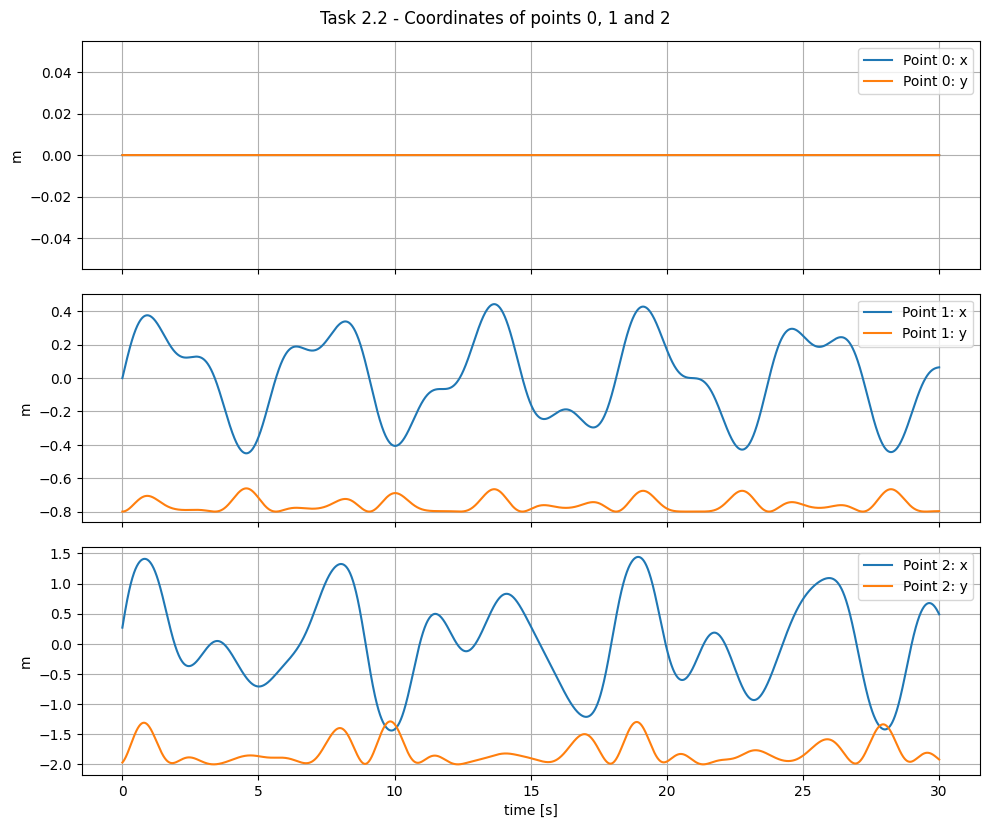

In [25]:
t22 = np.linspace(0.0, T_STOP, 3500)
phi1 = 0.42 * np.sin(1.05 * t22) + 0.18 * np.sin(2.4 * t22)
phi2 = 0.58 * np.sin(1.75 * t22 + 0.4)

x0_22 = np.zeros_like(t22)
y0_22 = np.zeros_like(t22)

x1_22 = l1 * np.sin(phi1)
y1_22 = -l1 * np.cos(phi1)

x2_22 = x1_22 + l2 * np.sin(phi1 + phi2)
y2_22 = y1_22 - l2 * np.cos(phi1 + phi2)

L1_22 = np.hypot(x1_22 - x0_22, y1_22 - y0_22)
L2_22 = np.hypot(x2_22 - x1_22, y2_22 - y1_22)

points22 = [(x0_22, y0_22), (x1_22, y1_22), (x2_22, y2_22)]
stats22 = [
    [r"time $t$", t22],
    [r"link 1 $l_1$", L1_22],
    [r"link 2 $l_2$", L2_22],
]

_fps22 = (len(t22) - 1) / max(t22[-1] - t22[0], 1e-9)
ani22 = visualize_double_pendulum(
    points22,
    stats=stats22,
    dt=t22[1] - t22[0],
    trace_len=0.2,
    axes=True,
    show=False,
    close_fig=False,
    verbose=False,
)
export_animation_media(ani22, "task_2_2", fps=_fps22)

plot_coordinates(
    t22,
    points22,
    ["Point 0", "Point 1", "Point 2"],
    "Task 2.2 - Coordinates of points 0, 1 and 2",
)

ani22


### Task 2.2 — Explain the obtained result (from the plots)
Point zero is fixed pivot. Point/joint 1 and end point oscillate while tip has wider swing than joint 1 because it depends on both angles.




## Task 2.3 — Fixed base, end-effector on horizontal axis


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_3.mp4


Animation size has reached 20982221 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_3.html
Exported files: ['task_2_3.mp4', 'task_2_3.html']


/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_3.mp4

/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_3.html

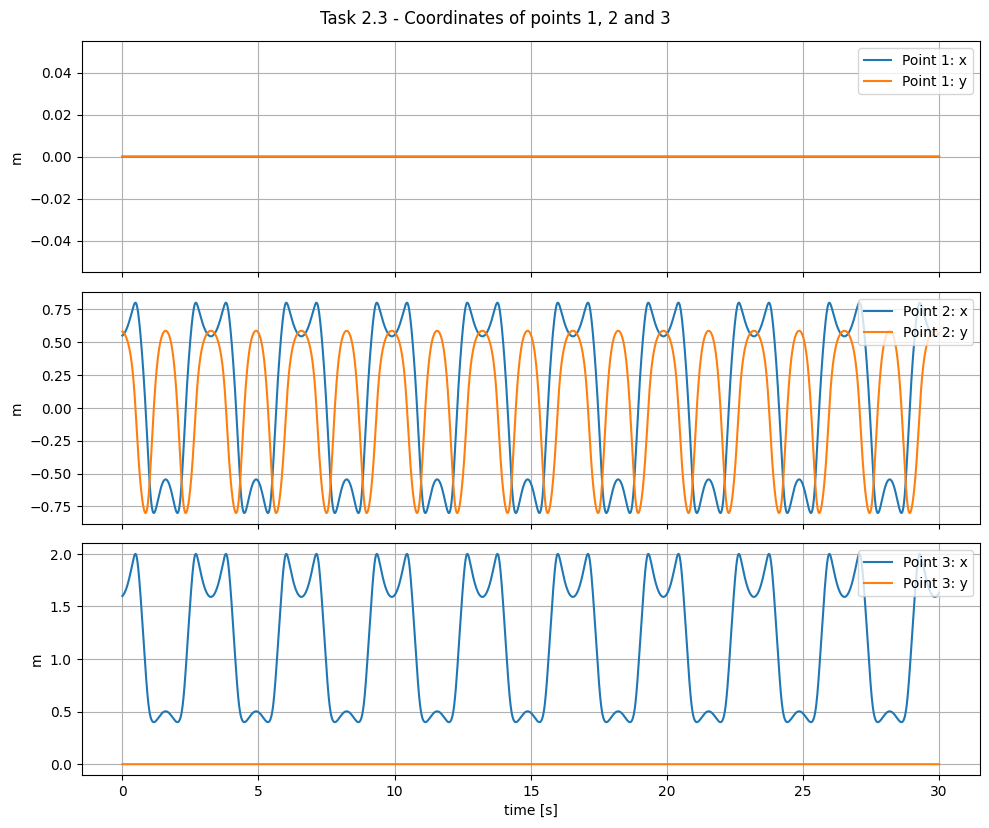

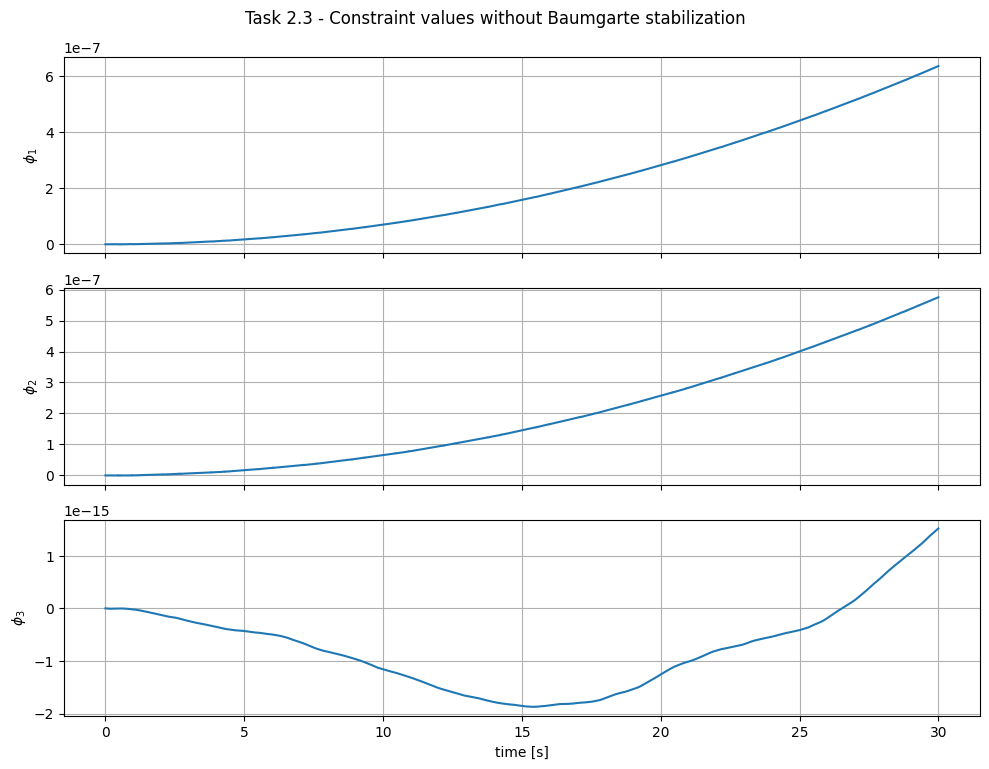

In [26]:
# State q = (x2,y2,x3,y3): joint 2 and end-effector (point 3). Base point 1 fixed at origin off-state.
def task23_phi(q):
    x2, y2, x3, y3 = q
    return np.array([
        0.5 * (x2**2 + y2**2 - l1**2),  # ||r2|| = l1  (equiv. to distance constraint)
        0.5 * ((x3 - x2)**2 + (y3 - y2)**2 - l2**2),
        y3,  # end-effector on horizontal axis
    ])


def task23_jacobian(q):
    x2, y2, x3, y3 = q
    return np.array([
        [x2, y2, 0.0, 0.0],
        [-(x3 - x2), -(y3 - y2), x3 - x2, y3 - y2],
        [0.0, 0.0, 0.0, 1.0],
    ])


def task23_jdot_qdot(qd):
    vx2, vy2, vx3, vy3 = qd
    return np.array([
        vx2**2 + vy2**2,
        (vx3 - vx2)**2 + (vy3 - vy2)**2,
        0.0,
    ])


def rhs_task23(t, y, alpha=0.0, beta=0.0):
    q = y[:4]
    qd = y[4:]
    M = np.diag([m1, m1, m2, m2])
    Q = np.array([0.0, -m1 * g, 0.0, -m2 * g])
    qdd, lam = constrained_acceleration(
        M,
        Q,
        task23_phi(q),
        task23_jacobian(q),
        task23_jdot_qdot(qd),
        qd,
        alpha=alpha,
        beta=beta,
    )
    return np.concatenate([qd, qdd])


def init_task23(endpoint_x=1.6):
    # Pick consistent IC on constraint manifold + velocity in ker(J).
    x3 = endpoint_x
    y3 = 0.0
    x2 = (endpoint_x**2 + l1**2 - l2**2) / (2.0 * endpoint_x)
    y2 = np.sqrt(l1**2 - x2**2)
    q0 = np.array([x2, y2, x3, y3])
    J0 = task23_jacobian(q0)
    qd0 = project_velocity(J0, np.array([0.35, -0.10, 0.15, 0.0]))
    return q0, qd0


t23 = np.linspace(0.0, T_STOP, 3500)
q0_23, qd0_23 = init_task23(endpoint_x=1.6)
y0_23 = np.concatenate([q0_23, qd0_23])
sol23 = integrate_system(lambda t, y: rhs_task23(t, y), y0_23, t23)

q23 = sol23.y[:4]
phi23 = np.array([task23_phi(q23[:, i]) for i in range(q23.shape[1])])

x1_23 = np.zeros_like(t23)
y1_23 = np.zeros_like(t23)
x2_23, y2_23, x3_23, y3_23 = q23

points23 = [(x1_23, y1_23), (x2_23, y2_23), (x3_23, y3_23)]
L1_23 = np.hypot(x2_23 - x1_23, y2_23 - y1_23)
L2_23 = np.hypot(x3_23 - x2_23, y3_23 - y2_23)

_fps23 = (len(t23) - 1) / max(t23[-1] - t23[0], 1e-9)
ani23 = visualize_double_pendulum(
    points23,
    stats=[
        [r"link 1 $l_1$", L1_23],
        [r"link 2 $l_2$", L2_23],
        [r"point 3 $y$", y3_23],
    ],
    dt=t23[1] - t23[0],
    trace_len=0.2,
    axes=True,
    show=False,
    close_fig=False,
    verbose=False,
)
export_animation_media(ani23, "task_2_3", fps=_fps23)

plot_coordinates(
    t23,
    points23,
    ["Point 1", "Point 2", "Point 3"],
    "Task 2.3 - Coordinates of points 1, 2 and 3",
)
plot_constraint_history(
    t23,
    phi23,
    [r"$\phi_1$", r"$\phi_2$", r"$\phi_3$"],
    "Task 2.3 - Constraint values without Baumgarte stabilization",
)

ani23


### Task 2.3 — How did you set the constraints?

Two distance constraints |r_2|= l_1, |r_3 - r_2| = l_2 plus (y_3=0); base fixed by omitting (x_1,y_1)) from (q).



## Task 2.4 — Base translates horizontally


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_4.mp4


Animation size has reached 20971675 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_4.html
Exported files: ['task_2_4.mp4', 'task_2_4.html']


/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_4.mp4

/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB05/exports/task_2_4.html

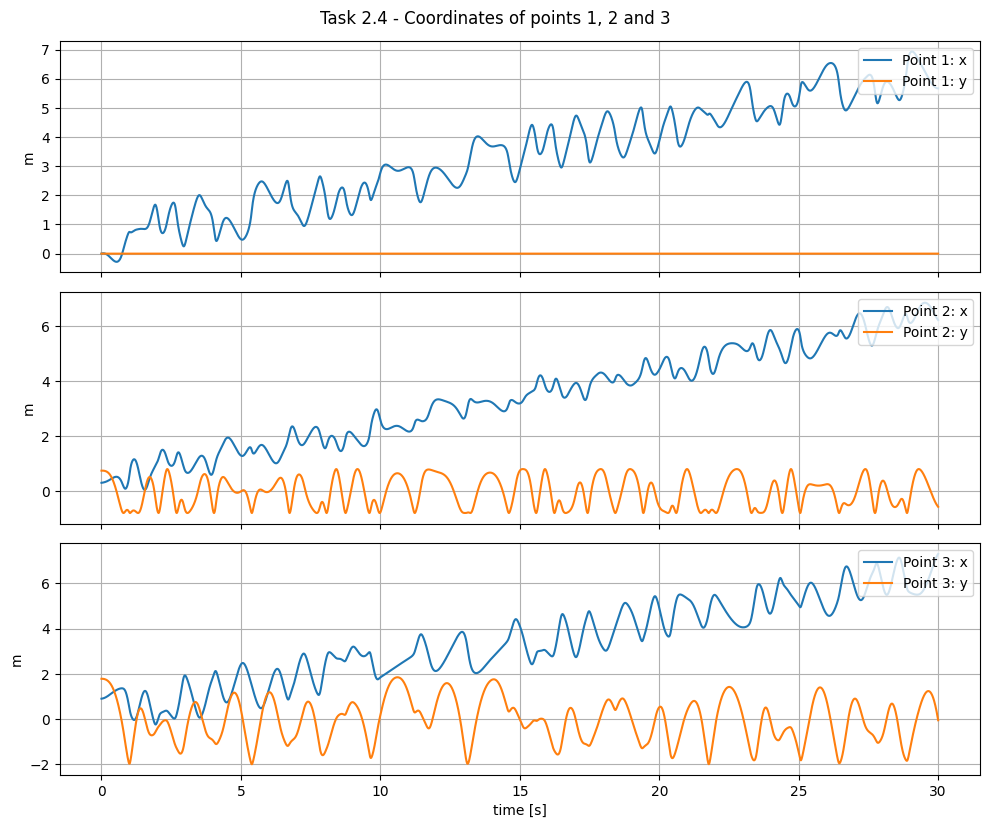

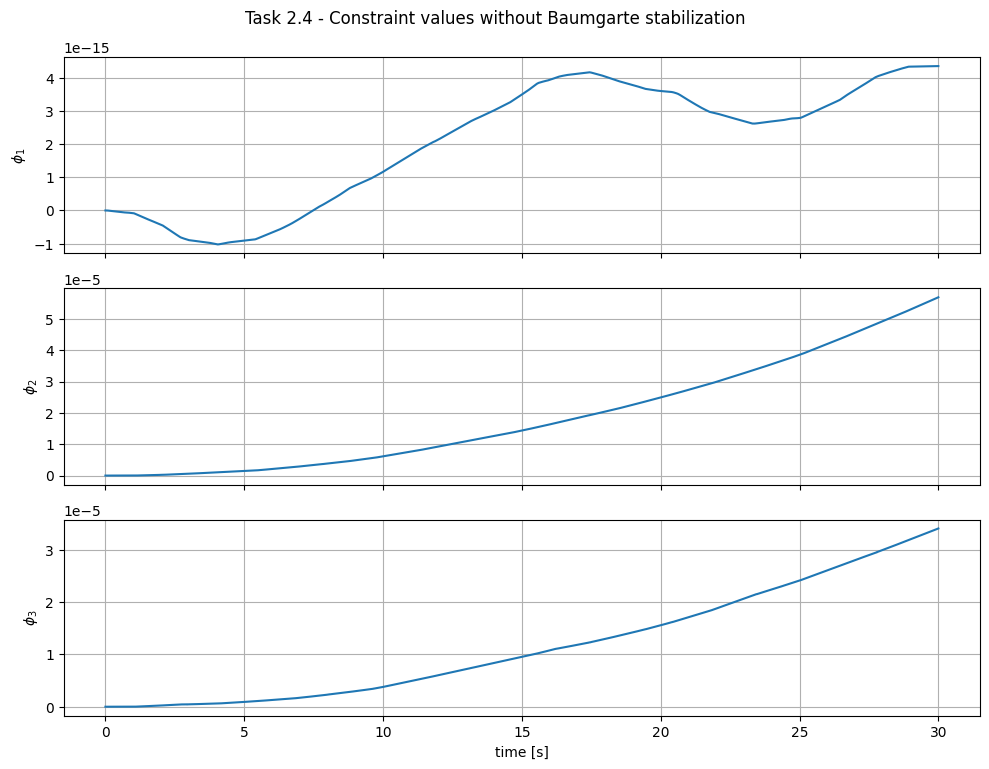

In [27]:
# State q = (x1,y1,x2,y2,x3,y3); base can slide horizontally (y1 constrained to 0).
def task24_phi(q):
    x1, y1, x2, y2, x3, y3 = q
    return np.array([
        y1,  # base on x-axis
        0.5 * ((x2 - x1)**2 + (y2 - y1)**2 - l1**2),
        0.5 * ((x3 - x2)**2 + (y3 - y2)**2 - l2**2),
    ])


def task24_jacobian(q):
    x1, y1, x2, y2, x3, y3 = q
    return np.array([
        [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
        [-(x2 - x1), -(y2 - y1), x2 - x1, y2 - y1, 0.0, 0.0],
        [0.0, 0.0, -(x3 - x2), -(y3 - y2), x3 - x2, y3 - y2],
    ])


def task24_jdot_qdot(qd):
    vx1, vy1, vx2, vy2, vx3, vy3 = qd
    return np.array([
        0.0,
        (vx2 - vx1)**2 + (vy2 - vy1)**2,
        (vx3 - vx2)**2 + (vy3 - vy2)**2,
    ])


def rhs_task24(t, y, alpha=0.0, beta=0.0):
    q = y[:6]
    qd = y[6:]
    M = np.diag([m0, m0, m1, m1, m2, m2])
    Q = np.array([0.0, -m0 * g, 0.0, -m1 * g, 0.0, -m2 * g])
    qdd, lam = constrained_acceleration(
        M,
        Q,
        task24_phi(q),
        task24_jacobian(q),
        task24_jdot_qdot(qd),
        qd,
        alpha=alpha,
        beta=beta,
    )
    return np.concatenate([qd, qdd])


def init_task24():
    x1, y1 = 0.0, 0.0
    x2, y2 = 0.30, np.sqrt(l1**2 - 0.30**2)
    x3, y3 = 0.90, y2 + np.sqrt(l2**2 - 0.60**2)
    q0 = np.array([x1, y1, x2, y2, x3, y3])
    J0 = task24_jacobian(q0)
    qd0 = project_velocity(J0, np.array([0.50, 0.00, 0.00, -0.20, 0.10, 0.00]))
    return q0, qd0


t24 = np.linspace(0.0, T_STOP, 3500)
q0_24, qd0_24 = init_task24()
y0_24 = np.concatenate([q0_24, qd0_24])
sol24 = integrate_system(lambda t, y: rhs_task24(t, y), y0_24, t24)

q24 = sol24.y[:6]
phi24 = np.array([task24_phi(q24[:, i]) for i in range(q24.shape[1])])

x1_24, y1_24, x2_24, y2_24, x3_24, y3_24 = q24
points24 = [(x1_24, y1_24), (x2_24, y2_24), (x3_24, y3_24)]
L1_24 = np.hypot(x2_24 - x1_24, y2_24 - y1_24)
L2_24 = np.hypot(x3_24 - x2_24, y3_24 - y2_24)

_fps24 = (len(t24) - 1) / max(t24[-1] - t24[0], 1e-9)
ani24 = visualize_double_pendulum(
    points24,
    stats=[
        [r"link 1 $l_1$", L1_24],
        [r"link 2 $l_2$", L2_24],
        [r"base $y_1$", y1_24],
    ],
    dt=t24[1] - t24[0],
    trace_len=0.2,
    axes=True,
    show=False,
    close_fig=False,
    verbose=False,
)
export_animation_media(ani24, "task_2_4", fps=_fps24)

plot_coordinates(
    t24,
    points24,
    ["Point 1", "Point 2", "Point 3"],
    "Task 2.4 - Coordinates of points 1, 2 and 3",
)
plot_constraint_history(
    t24,
    phi24,
    [r"$\phi_1$", r"$\phi_2$", r"$\phi_3$"],
    "Task 2.4 - Constraint values without Baumgarte stabilization",
)

ani24


## Task 2.5


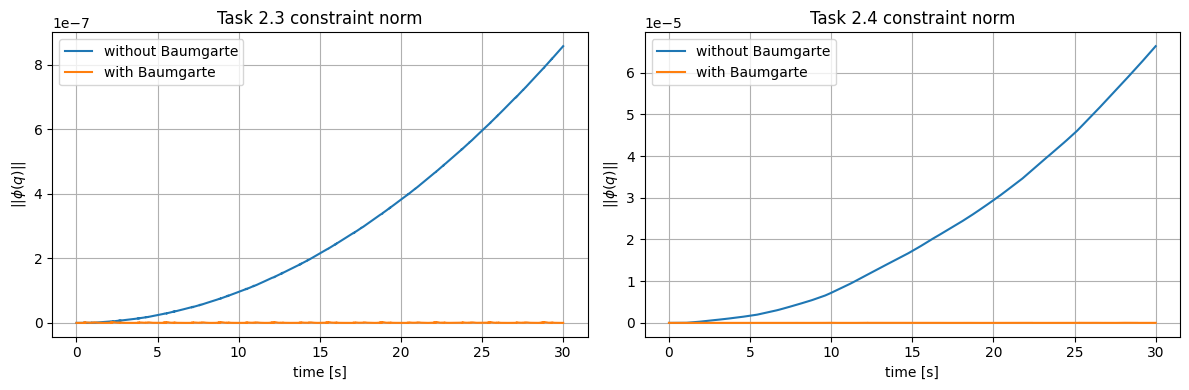

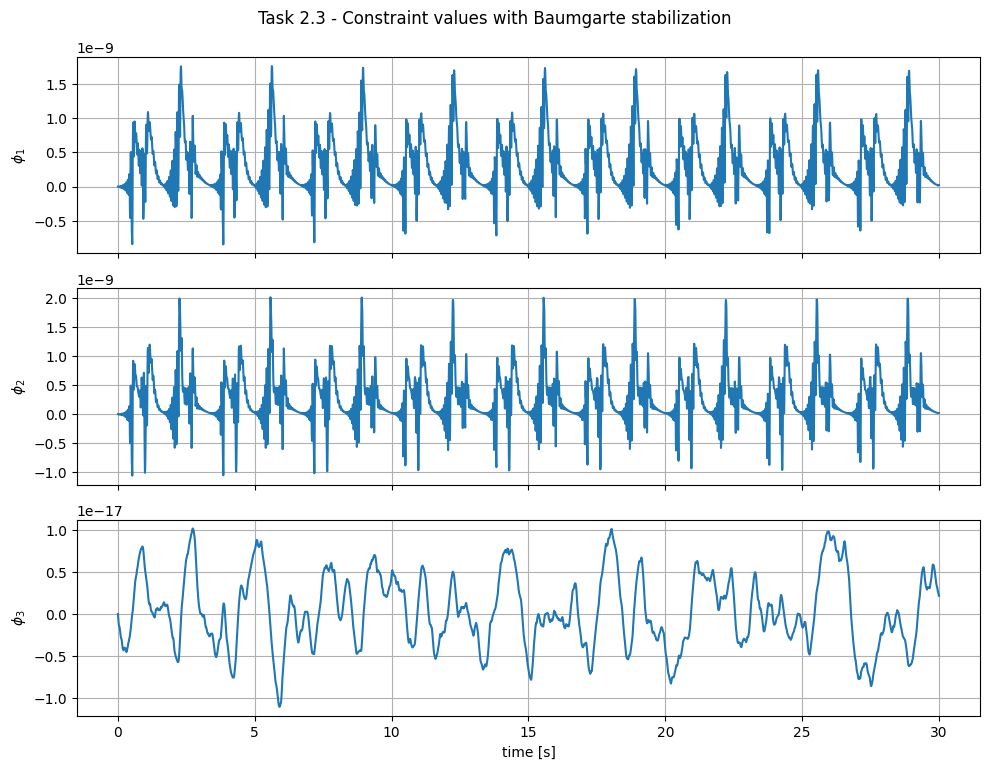

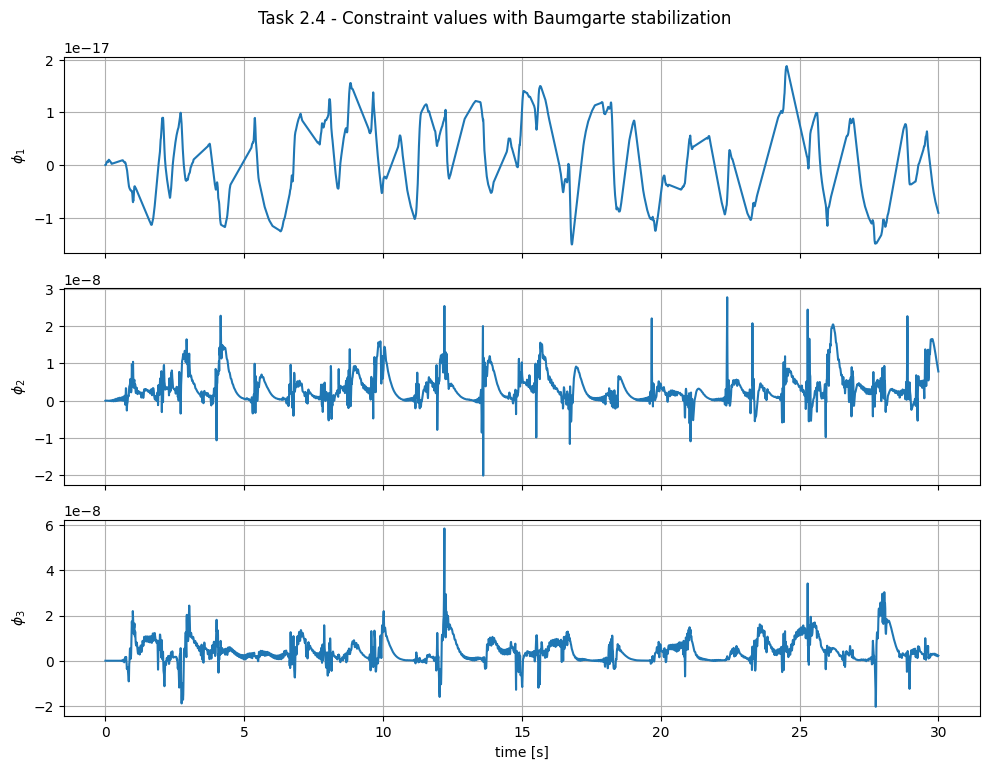

In [28]:
# Baumgarte: J qdd = -J̇q̇ - 2α J q̇ - β² φ  (implemented inside constrained_acceleration)
alpha = 8.0
beta = 8.0

sol23_bg = integrate_system(lambda t, y: rhs_task23(t, y, alpha=alpha, beta=beta), y0_23, t23)
q23_bg = sol23_bg.y[:4]
phi23_bg = np.array([task23_phi(q23_bg[:, i]) for i in range(q23_bg.shape[1])])

sol24_bg = integrate_system(lambda t, y: rhs_task24(t, y, alpha=alpha, beta=beta), y0_24, t24)
q24_bg = sol24_bg.y[:6]
phi24_bg = np.array([task24_phi(q24_bg[:, i]) for i in range(q24_bg.shape[1])])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].plot(t23, constraint_norm(phi23), label="without Baumgarte")
axes[0].plot(t23, constraint_norm(phi23_bg), label="with Baumgarte")
axes[0].set_title("Task 2.3 constraint norm")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel(r"$||\phi(q)||$")
axes[0].legend()

axes[1].plot(t24, constraint_norm(phi24), label="without Baumgarte")
axes[1].plot(t24, constraint_norm(phi24_bg), label="with Baumgarte")
axes[1].set_title("Task 2.4 constraint norm")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel(r"$||\phi(q)||$")
axes[1].legend()

plt.tight_layout()

plot_constraint_history(
    t23,
    phi23_bg,
    [r"$\phi_1$", r"$\phi_2$", r"$\phi_3$"],
    "Task 2.3 - Constraint values with Baumgarte stabilization",
)
plot_constraint_history(
    t24,
    phi24_bg,
    [r"$\phi_1$", r"$\phi_2$", r"$\phi_3$"],
    "Task 2.4 - Constraint values with Baumgarte stabilization",
)
